## Iterative Training of First-Phase Structural Models

This notebook trains separate XGBoost regressors for `Grain_1`,
`a_1`, `b_1`, and `c_1` using datasets from iterations 3–6.

### Workflow

1. Independently split each dataset into training and test sets (80/20).
2. Select the top 15 features using training data.
3. Train regressors and evaluate R², MAE, and RMSE.
4. Save models, selected features, predictions, and performance metrics.

`Grain_1` is trained using log1p-transformed targets, with exported
predictions and metrics converted back to the original scale.
The lattice parameters are modeled directly on their original scales.

Each target section can run independently. Run all cells within a
section sequentially, including the export step, before switching targets.
Splits are row-based; no cross-validation is performed.

## Grain1

In [1]:
# ============================================================
# 1. Import packages
# ============================================================

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

In [2]:
# ============================================================
# 2. Load data and randomly split each dataset
# ============================================================

DATA_FILES = {
    "Iteration_3": "data/compound_3_Structural_Grain1.csv",
    "Iteration_4": "data/compound_4_Structural_Grain1.csv",
    "Iteration_5": "data/compound_5_Structural_Grain1.csv",
    "Iteration_6": "data/compound_6_Structural_Grain1.csv"
}

TARGET_COL = "Grain_1"
COMPOUND_COL = "compound"

RANDOM_STATE = 2027
TEST_SIZE = 0.20


# Store data from all iterations
iteration_data = {}


for iteration_name, data_file in DATA_FILES.items():

    # Load data
    data = pd.read_csv(data_file)

    # Remove automatically generated index columns
    data = data.loc[
        :,
        ~data.columns.str.startswith("Unnamed")
    ].copy()

    # Features
    X = (
        data
        .drop(
            columns=[
                TARGET_COL,
                COMPOUND_COL
            ],
            errors="ignore"
        )
        .apply(
            pd.to_numeric,
            errors="raise"
        )
    )

    # Original Grain1 values
    y_original = (
        data[TARGET_COL]
        .astype(float)
    )

    # Check Grain1 values before log transformation
    if (y_original < 0).any():

        raise ValueError(
            f"{iteration_name} contains negative Grain1 values."
        )

    # Log transformation
    y_log = np.log1p(
        y_original
    )


    # Randomly split each dataset
    (
        X_train,
        X_test,
        y_train_log,
        y_test_log
    ) = train_test_split(
        X,
        y_log,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE
    )


    # Store the current iteration data
    iteration_data[iteration_name] = {
        "data_file": data_file,
        "data": data,
        "X_train": X_train,
        "X_test": X_test,
        "y_train_log": y_train_log,
        "y_test_log": y_test_log
    }


    print("\n" + "=" * 70)
    print(iteration_name)
    print("=" * 70)

    print("Dataset shape:", data.shape)
    print("Training samples:", len(X_train))
    print("Test samples:", len(X_test))

    print(
        "Training log target range:",
        round(y_train_log.min(), 4),
        "to",
        round(y_train_log.max(), 4)
    )

    print(
        "Test log target range:",
        round(y_test_log.min(), 4),
        "to",
        round(y_test_log.max(), 4)
    )


Iteration_3
Dataset shape: (125, 27)
Training samples: 100
Test samples: 25
Training log target range: 1.9169 to 4.6092
Test log target range: 1.9169 to 4.6977

Iteration_4
Dataset shape: (133, 27)
Training samples: 106
Test samples: 27
Training log target range: 1.7918 to 4.6092
Test log target range: 1.9169 to 4.6977

Iteration_5
Dataset shape: (145, 27)
Training samples: 116
Test samples: 29
Training log target range: 1.7918 to 4.6092
Test log target range: 1.9315 to 4.6977

Iteration_6
Dataset shape: (160, 27)
Training samples: 128
Test samples: 32
Training log target range: 1.0296 to 4.6977
Test log target range: 1.0647 to 4.5042


In [3]:
# ============================================================
# 3. Feature selection
# ============================================================

for iteration_name, iteration in iteration_data.items():

    X_train = iteration["X_train"]
    X_test = iteration["X_test"]

    y_train_log = iteration["y_train_log"]


    # Initial model for feature selection
    reg_selector = XGBRegressor(
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        reg_alpha=1,
        reg_lambda=1,
        n_estimators=200,
        max_depth=8,
        learning_rate=0.1
    )

    reg_selector.fit(
        X_train,
        y_train_log
    )


    # Extract feature importance
    feature_importance = (
        reg_selector.feature_importances_
    )

    feature_names = (
        X_train.columns.to_numpy()
    )


    # Keep the top 15 features
    num_features_to_keep = min(
        15,
        X_train.shape[1]
    )

    top_idx = np.argsort(
        feature_importance
    )[::-1][:num_features_to_keep]

    selected_features = (
        feature_names[top_idx]
        .tolist()
    )


    # Select training and test features
    X_train_selected = (
        X_train[selected_features]
        .copy()
    )

    X_test_selected = (
        X_test[selected_features]
        .copy()
    )


    # Store feature-selection results
    iteration["reg_selector"] = (
        reg_selector
    )

    iteration["selected_features"] = (
        selected_features
    )

    iteration["X_train_selected"] = (
        X_train_selected
    )

    iteration["X_test_selected"] = (
        X_test_selected
    )


    print("\n" + "=" * 70)
    print(iteration_name)
    print("=" * 70)

    print("Selected features:")
    print(selected_features)


Iteration_3
Selected features:
['C_CR', 'C_EA', 'AB_Nd', 'AB_FIE', 'AB_AR', 'AB_AN', 'AB_SIE', 'C_D', 'AB_CR', 'C_AN', 'AB_EC', 'AB_D', 'AB_TC', 'AB_AW', 'AB_EA']

Iteration_4
Selected features:
['C_CR', 'AB_AR', 'AB_D', 'AB_AN', 'C_EA', 'AB_FIE', 'C_AN', 'AB_Nd', 'AB_SIE', 'AB_Nv', 'AB_EA', 'C_D', 'AB_TC', 'AB_CR', 'C_FIE']

Iteration_5
Selected features:
['C_EA', 'AB_AR', 'C_FIE', 'C_AN', 'C_SIE', 'AB_AN', 'AB_Nd', 'AB_Nv', 'C_CR', 'AB_EN', 'C_D', 'AB_SIE', 'C_AW', 'AB_EA', 'AB_AW']

Iteration_6
Selected features:
['C_FIE', 'C_EA', 'C_D', 'AB_AN', 'C_AN', 'AB_Nv', 'AB_AR', 'AB_EN', 'AB_FIE', 'AB_Nd', 'AB_AW', 'C_CR', 'AB_SIE', 'AB_CR', 'AB_D']



Iteration_3
Model performance in log space:
           R2     MAE    RMSE
Train  0.9150  0.1494  0.1952
Test   0.5174  0.3581  0.5140


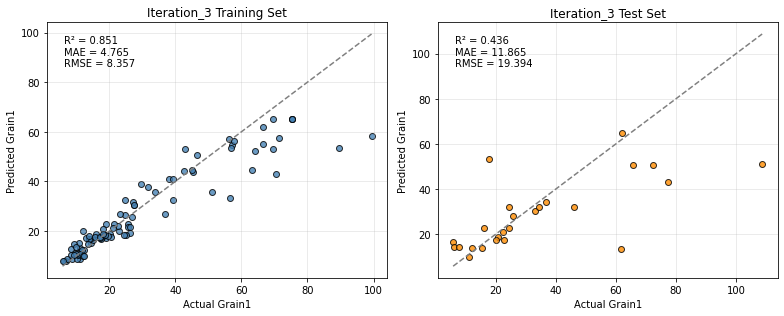


Iteration_4
Model performance in log space:
           R2     MAE    RMSE
Train  0.9401  0.1338  0.1743
Test   0.5182  0.3841  0.5406


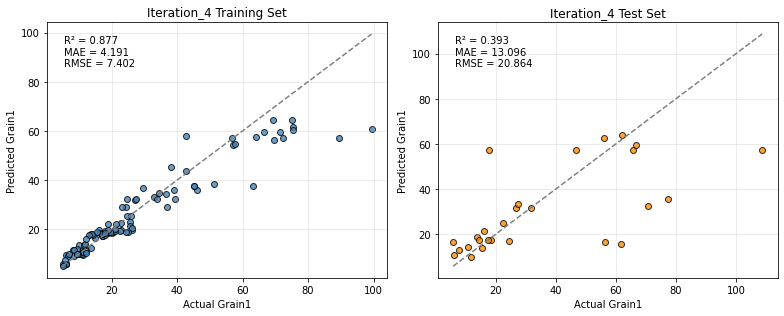


Iteration_5
Model performance in log space:
           R2     MAE    RMSE
Train  0.9263  0.1431  0.1905
Test   0.6376  0.3295  0.4436


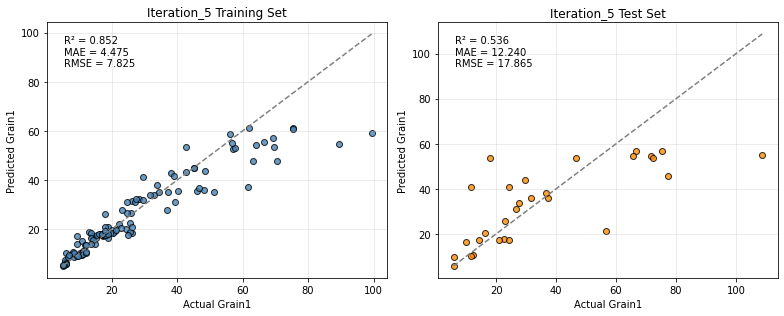


Iteration_6
Model performance in log space:
           R2     MAE    RMSE
Train  0.9359  0.1507  0.2134
Test   0.8264  0.3021  0.4130


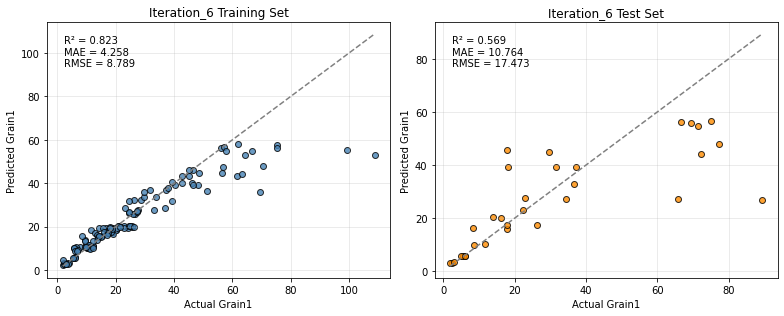

In [5]:
# ============================================================
# 4. Train and evaluate the models
# ============================================================

os.makedirs(
    "figure/grain1_iterations",
    exist_ok=True
)


# Calculate regression metrics in log space
def calculate_metrics(
    y_true_log,
    y_pred_log
):

    return {
        "R2": r2_score(
            y_true_log,
            y_pred_log
        ),
        "MAE": mean_absolute_error(
            y_true_log,
            y_pred_log
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_true_log,
                y_pred_log
            )
        )
    }


# Store all iteration metrics
all_metrics = []


for iteration_name, iteration in iteration_data.items():

    X_train_selected = (
        iteration["X_train_selected"]
    )

    X_test_selected = (
        iteration["X_test_selected"]
    )

    y_train_log = (
        iteration["y_train_log"]
    )

    y_test_log = (
        iteration["y_test_log"]
    )


    # --------------------------------------------------------
    # Train the final model using log-transformed Grain1
    # --------------------------------------------------------

    reg = XGBRegressor(
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        reg_alpha=1,
        reg_lambda=1,
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05
    )

    reg.fit(
        X_train_selected,
        y_train_log
    )


    # Predictions remain in log space
    train_pred_log = reg.predict(
        X_train_selected
    )

    test_pred_log = reg.predict(
        X_test_selected
    )


    # Calculate metrics in log space
    train_metrics = calculate_metrics(
        y_train_log,
        train_pred_log
    )

    test_metrics = calculate_metrics(
        y_test_log,
        test_pred_log
    )

    metrics_table = pd.DataFrame(
        [train_metrics, test_metrics],
        index=["Train", "Test"]
    )


    print("\n" + "=" * 70)
    print(iteration_name)
    print("=" * 70)

    print("Model performance in log space:")
    print(
        metrics_table.round(4)
    )


    # Store train metrics
    all_metrics.append({
        "Iteration": iteration_name,
        "Dataset": "Train",
        "Sample_Size": len(y_train_log),
        **train_metrics
    })

    # Store test metrics
    all_metrics.append({
        "Iteration": iteration_name,
        "Dataset": "Test",
        "Sample_Size": len(y_test_log),
        **test_metrics
    })


    # Store model results
    iteration["reg"] = reg

    iteration["train_pred_log"] = (
        train_pred_log
    )

    iteration["test_pred_log"] = (
        test_pred_log
    )

    iteration["train_metrics"] = (
        train_metrics
    )

    iteration["test_metrics"] = (
        test_metrics
    )


    # --------------------------------------------------------
    # Convert predictions back to the original Grain1 scale
    # --------------------------------------------------------

    y_train_original = np.expm1(
        np.asarray(y_train_log)
    )

    y_test_original = np.expm1(
        np.asarray(y_test_log)
    )

    train_pred_original = np.expm1(
        train_pred_log
    )

    test_pred_original = np.expm1(
        test_pred_log
    )


    # Calculate metrics on the original Grain1 scale
    train_metrics_original = calculate_metrics(
        y_train_original,
        train_pred_original
    )

    test_metrics_original = calculate_metrics(
        y_test_original,
        test_pred_original
    )


    # Store original-scale results
    iteration["y_train_original"] = (
        y_train_original
    )

    iteration["y_test_original"] = (
        y_test_original
    )

    iteration["train_pred_original"] = (
        train_pred_original
    )

    iteration["test_pred_original"] = (
        test_pred_original
    )

    iteration["train_metrics_original"] = (
        train_metrics_original
    )

    iteration["test_metrics_original"] = (
        test_metrics_original
    )


    # --------------------------------------------------------
    # Plot model performance on the original Grain1 scale
    # --------------------------------------------------------

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(11, 4.5)
    )


    # Training set
    axes[0].scatter(
        y_train_original,
        train_pred_original,
        color="steelblue",
        edgecolor="black",
        alpha=0.8
    )

    train_min = min(
        y_train_original.min(),
        train_pred_original.min()
    )

    train_max = max(
        y_train_original.max(),
        train_pred_original.max()
    )

    axes[0].plot(
        [train_min, train_max],
        [train_min, train_max],
        color="gray",
        linestyle="--"
    )

    axes[0].set_xlabel(
        "Actual Grain1"
    )

    axes[0].set_ylabel(
        "Predicted Grain1"
    )

    axes[0].set_title(
        f"{iteration_name} Training Set"
    )

    axes[0].text(
        0.05,
        0.95,
        (
            f"R² = {train_metrics_original['R2']:.3f}\n"
            f"MAE = {train_metrics_original['MAE']:.3f}\n"
            f"RMSE = {train_metrics_original['RMSE']:.3f}"
        ),
        transform=axes[0].transAxes,
        verticalalignment="top"
    )

    axes[0].grid(
        alpha=0.3
    )


    # Test set
    axes[1].scatter(
        y_test_original,
        test_pred_original,
        color="darkorange",
        edgecolor="black",
        alpha=0.8
    )

    test_min = min(
        y_test_original.min(),
        test_pred_original.min()
    )

    test_max = max(
        y_test_original.max(),
        test_pred_original.max()
    )

    axes[1].plot(
        [test_min, test_max],
        [test_min, test_max],
        color="gray",
        linestyle="--"
    )

    axes[1].set_xlabel(
        "Actual Grain1"
    )

    axes[1].set_ylabel(
        "Predicted Grain1"
    )

    axes[1].set_title(
        f"{iteration_name} Test Set"
    )

    axes[1].text(
        0.05,
        0.95,
        (
            f"R² = {test_metrics_original['R2']:.3f}\n"
            f"MAE = {test_metrics_original['MAE']:.3f}\n"
            f"RMSE = {test_metrics_original['RMSE']:.3f}"
        ),
        transform=axes[1].transAxes,
        verticalalignment="top"
    )

    axes[1].grid(
        alpha=0.3
    )


    plt.tight_layout()

    plt.show()

In [6]:
# ============================================================
# 5. Save models, selected features and original-scale results
# ============================================================

os.makedirs(
    "model/grain1_iterations",
    exist_ok=True
)

os.makedirs(
    "result/grain1_iterations",
    exist_ok=True
)


# Store metrics on the original Grain1 scale
all_metrics_original = []


for iteration_name, iteration in iteration_data.items():

    iteration_number = (
        iteration_name.split("_")[-1]
    )

    reg = iteration["reg"]

    selected_features = (
        iteration["selected_features"]
    )

    y_train_log = (
        iteration["y_train_log"]
    )

    y_test_log = (
        iteration["y_test_log"]
    )

    train_pred_log = (
        iteration["train_pred_log"]
    )

    test_pred_log = (
        iteration["test_pred_log"]
    )


    # --------------------------------------------------------
    # Convert values back to the original Grain1 scale
    # --------------------------------------------------------

    y_train_original = np.expm1(
        np.asarray(y_train_log)
    )

    y_test_original = np.expm1(
        np.asarray(y_test_log)
    )

    train_pred_original = np.expm1(
        train_pred_log
    )

    test_pred_original = np.expm1(
        test_pred_log
    )


    # Calculate metrics on the original Grain1 scale
    train_metrics_original = calculate_metrics(
        y_train_original,
        train_pred_original
    )

    test_metrics_original = calculate_metrics(
        y_test_original,
        test_pred_original
    )


    # Store original-scale metrics
    all_metrics_original.append({
        "Iteration": iteration_name,
        "Dataset": "Train",
        "Sample_Size": len(y_train_original),
        **train_metrics_original
    })

    all_metrics_original.append({
        "Iteration": iteration_name,
        "Dataset": "Test",
        "Sample_Size": len(y_test_original),
        **test_metrics_original
    })


    # --------------------------------------------------------
    # Save model
    # --------------------------------------------------------

    joblib.dump(
        reg,
        (
            "model/grain1_iterations/"
            f"xgb_structural_grain1_{iteration_number}.pkl"
        )
    )


    # --------------------------------------------------------
    # Save selected features
    # --------------------------------------------------------

    np.save(
        (
            "model/grain1_iterations/"
            f"selected_features_structural_grain1_"
            f"{iteration_number}.npy"
        ),
        np.array(selected_features)
    )


    # --------------------------------------------------------
    # Save training predictions on the original scale
    # --------------------------------------------------------

    train_predictions = pd.DataFrame({
        "Actual_Grain1": y_train_original,
        "Predicted_Grain1": train_pred_original
    })

    train_predictions.to_csv(
        (
            "result/grain1_iterations/"
            f"Iteration_{iteration_number}_"
            "train_predictions.csv"
        ),
        index=False
    )


    # --------------------------------------------------------
    # Save test predictions on the original scale
    # --------------------------------------------------------

    test_predictions = pd.DataFrame({
        "Actual_Grain1": y_test_original,
        "Predicted_Grain1": test_pred_original
    })

    test_predictions.to_csv(
        (
            "result/grain1_iterations/"
            f"Iteration_{iteration_number}_"
            "test_predictions.csv"
        ),
        index=False
    )


    print(
        f"Iteration_{iteration_number} files saved."
    )


# ============================================================
# Save all iteration metrics on the original scale
# ============================================================

all_metrics_original_table = pd.DataFrame(
    all_metrics_original
)

all_metrics_original_table.to_csv(
    (
        "result/grain1_iterations/"
        "grain1_iteration_metrics_original.csv"
    ),
    index=False
)


# ============================================================
# Display test-set comparison on the original scale
# ============================================================

test_metrics_table = (
    all_metrics_original_table[
        all_metrics_original_table["Dataset"] == "Test"
    ]
    .reset_index(drop=True)
)


print("\n" + "=" * 70)
print("Test performance comparison on the original Grain1 scale")
print("=" * 70)

print(
    test_metrics_table.round(4)
)

Iteration_3 files saved.
Iteration_4 files saved.
Iteration_5 files saved.
Iteration_6 files saved.

Test performance comparison on the original Grain1 scale
     Iteration Dataset  Sample_Size      R2      MAE     RMSE
0  Iteration_3    Test           25  0.4362  11.8653  19.3945
1  Iteration_4    Test           27  0.3934  13.0957  20.8638
2  Iteration_5    Test           29  0.5362  12.2400  17.8653
3  Iteration_6    Test           32  0.5690  10.7643  17.4733


## a1

In [1]:
# ============================================================
# 1. Import packages
# ============================================================

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

In [3]:
# ============================================================
# 2. Load data and randomly split each dataset
# ============================================================

DATA_FILES = {
    "Iteration_3": "data/compound_3_Structural_a1.csv",
    "Iteration_4": "data/compound_4_Structural_a1.csv",
    "Iteration_5": "data/compound_5_Structural_a1.csv",
    "Iteration_6": "data/compound_6_Structural_a1.csv"
}

TARGET_COL = "a_1"
COMPOUND_COL = "compound"

RANDOM_STATE = 42
TEST_SIZE = 0.20


# Store data from all iterations
iteration_data = {}


for iteration_name, data_file in DATA_FILES.items():

    # Load data
    data = pd.read_csv(data_file)

    # Remove automatically generated index columns
    data = data.loc[
        :,
        ~data.columns.str.startswith("Unnamed")
    ].copy()

    # Features
    X = (
        data
        .drop(
            columns=[
                TARGET_COL,
                COMPOUND_COL
            ],
            errors="ignore"
        )
        .apply(
            pd.to_numeric,
            errors="raise"
        )
    )

    # Target
    y = (
        data[TARGET_COL]
        .astype(float)
    )

    # Randomly split each dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE
    )

    # Store the current iteration data
    iteration_data[iteration_name] = {
        "data_file": data_file,
        "data": data,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test
    }

    print("\n" + "=" * 70)
    print(iteration_name)
    print("=" * 70)

    print("Dataset shape:", data.shape)
    print("Training samples:", len(X_train))
    print("Test samples:", len(X_test))

    print(
        "Training target range:",
        round(y_train.min(), 4),
        "to",
        round(y_train.max(), 4)
    )

    print(
        "Test target range:",
        round(y_test.min(), 4),
        "to",
        round(y_test.max(), 4)
    )




Iteration_3
Dataset shape: (125, 27)
Training samples: 100
Test samples: 25
Training target range: 4.1115 to 8.5201
Test target range: 3.9685 to 11.526

Iteration_4
Dataset shape: (133, 27)
Training samples: 106
Test samples: 27
Training target range: 3.9685 to 11.526
Test target range: 4.1345 to 8.1464

Iteration_5
Dataset shape: (145, 27)
Training samples: 116
Test samples: 29
Training target range: 3.4249 to 11.526
Test target range: 3.4611 to 9.6359

Iteration_6
Dataset shape: (160, 27)
Training samples: 128
Test samples: 32
Training target range: 3.1015 to 11.526
Test target range: 3.4611 to 8.2027


In [4]:
# ============================================================
# 3. Feature selection
# ============================================================

for iteration_name, iteration in iteration_data.items():

    X_train = iteration["X_train"]
    X_test = iteration["X_test"]
    y_train = iteration["y_train"]

    # Initial model for feature selection
    reg_selector = XGBRegressor(
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        reg_alpha=1,
        reg_lambda=1,
        n_estimators=200,
        max_depth=8,
        learning_rate=0.1
    )

    reg_selector.fit(
        X_train,
        y_train
    )

    # Extract feature importance
    feature_importance = (
        reg_selector.feature_importances_
    )

    feature_names = (
        X_train.columns.to_numpy()
    )

    # Keep the top 15 features
    num_features_to_keep = min(
        15,
        X_train.shape[1]
    )

    top_idx = np.argsort(
        feature_importance
    )[::-1][:num_features_to_keep]

    selected_features = (
        feature_names[top_idx]
        .tolist()
    )

    # Select training and test features
    X_train_selected = (
        X_train[selected_features]
        .copy()
    )

    X_test_selected = (
        X_test[selected_features]
        .copy()
    )

    # Store feature-selection results
    iteration["reg_selector"] = reg_selector

    iteration["selected_features"] = (
        selected_features
    )

    iteration["X_train_selected"] = (
        X_train_selected
    )

    iteration["X_test_selected"] = (
        X_test_selected
    )

    print("\n" + "=" * 70)
    print(iteration_name)
    print("=" * 70)

    print("Selected features:")
    print(selected_features)



Iteration_3
Selected features:
['C_AN', 'C_CR', 'AB_AN', 'AB_FIE', 'AB_SIE', 'AB_Nd', 'AB_Nv', 'AB_CR', 'AB_AR', 'AB_EA', 'AB_AW', 'C_AW', 'AB_EC', 'AB_TC', 'AB_EN']

Iteration_4
Selected features:
['C_CR', 'C_AN', 'C_VR', 'AB_SIE', 'AB_FIE', 'AB_AN', 'AB_D', 'AB_EN', 'AB_Nd', 'AB_AW', 'AB_Nv', 'AB_AR', 'AB_TC', 'AB_CR', 'AB_EA']

Iteration_5
Selected features:
['C_D', 'C_FIE', 'AB_EA', 'AB_AN', 'C_CR', 'C_AN', 'C_SIE', 'AB_FIE', 'AB_EN', 'AB_SIE', 'AB_EC', 'AB_D', 'AB_CR', 'AB_Nv', 'AB_AW']

Iteration_6
Selected features:
['C_FIE', 'C_CR', 'C_AW', 'AB_EA', 'C_AN', 'AB_AW', 'AB_AN', 'AB_CR', 'AB_EN', 'AB_D', 'C_SIE', 'C_VR', 'AB_FIE', 'AB_Nv', 'AB_SIE']



Iteration_3
Model performance:
           R2     MAE    RMSE
Train  0.9973  0.0472  0.0874
Test   0.8262  0.2941  0.7946


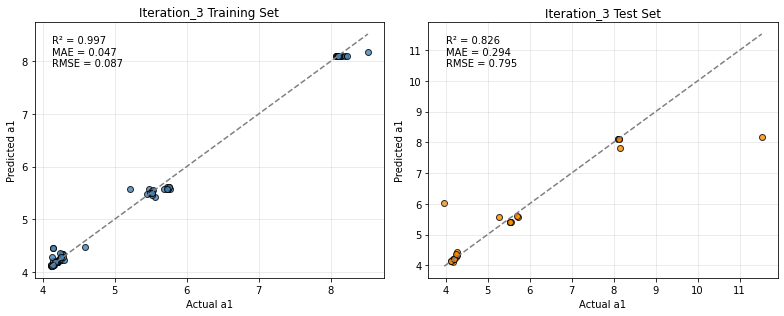


Iteration_4
Model performance:
           R2     MAE    RMSE
Train  0.9925  0.0625  0.1497
Test   0.9521  0.1856  0.3284


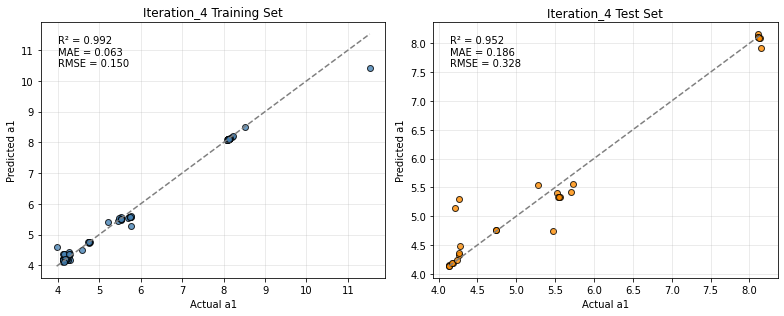


Iteration_5
Model performance:
           R2     MAE    RMSE
Train  0.9919  0.0781  0.1708
Test   0.9579  0.1553  0.3965


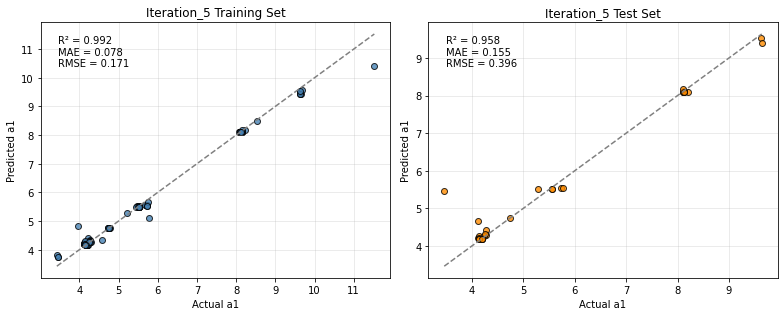


Iteration_6
Model performance:
           R2     MAE   RMSE
Train  0.9870  0.1268  0.232
Test   0.9827  0.1296  0.203


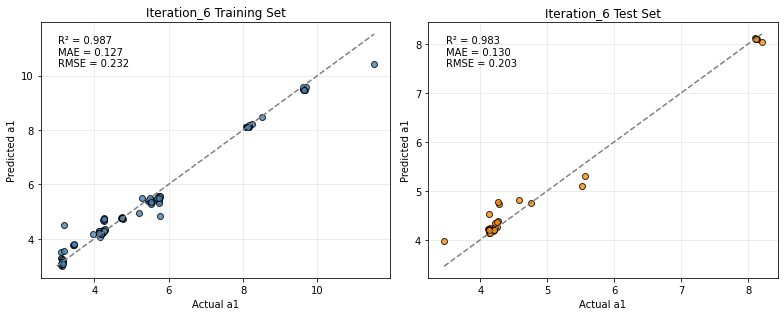

In [5]:
# ============================================================
# 4. Train and evaluate the models
# ============================================================

os.makedirs(
    "figure/a1_iterations",
    exist_ok=True
)


def calculate_metrics(
    y_true,
    y_pred
):

    return {
        "R2": r2_score(
            y_true,
            y_pred
        ),
        "MAE": mean_absolute_error(
            y_true,
            y_pred
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_true,
                y_pred
            )
        )
    }


# Store all iteration metrics
all_metrics = []


for iteration_name, iteration in iteration_data.items():

    X_train_selected = (
        iteration["X_train_selected"]
    )

    X_test_selected = (
        iteration["X_test_selected"]
    )

    y_train = iteration["y_train"]
    y_test = iteration["y_test"]


    # Train the final model
    reg = XGBRegressor(
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        reg_alpha=1,
        reg_lambda=1,
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05
    )

    reg.fit(
        X_train_selected,
        y_train
    )


    # Predictions
    train_pred = reg.predict(
        X_train_selected
    )

    test_pred = reg.predict(
        X_test_selected
    )


    # Calculate metrics using original a1 values
    train_metrics = calculate_metrics(
        y_train,
        train_pred
    )

    test_metrics = calculate_metrics(
        y_test,
        test_pred
    )

    metrics_table = pd.DataFrame(
        [train_metrics, test_metrics],
        index=["Train", "Test"]
    )


    print("\n" + "=" * 70)
    print(iteration_name)
    print("=" * 70)

    print("Model performance:")
    print(
        metrics_table.round(4)
    )


    # Store metrics
    all_metrics.append({
        "Iteration": iteration_name,
        "Dataset": "Train",
        "Sample_Size": len(y_train),
        **train_metrics
    })

    all_metrics.append({
        "Iteration": iteration_name,
        "Dataset": "Test",
        "Sample_Size": len(y_test),
        **test_metrics
    })


    # Store model results
    iteration["reg"] = reg
    iteration["train_pred"] = train_pred
    iteration["test_pred"] = test_pred
    iteration["train_metrics"] = train_metrics
    iteration["test_metrics"] = test_metrics


    # ========================================================
    # Plot model performance
    # ========================================================

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(11, 4.5)
    )


    # Training set
    axes[0].scatter(
        y_train,
        train_pred,
        color="steelblue",
        edgecolor="black",
        alpha=0.8
    )

    train_min = min(
        y_train.min(),
        train_pred.min()
    )

    train_max = max(
        y_train.max(),
        train_pred.max()
    )

    axes[0].plot(
        [train_min, train_max],
        [train_min, train_max],
        color="gray",
        linestyle="--"
    )

    axes[0].set_xlabel("Actual a1")
    axes[0].set_ylabel("Predicted a1")

    axes[0].set_title(
        f"{iteration_name} Training Set"
    )

    axes[0].text(
        0.05,
        0.95,
        (
            f"R² = {train_metrics['R2']:.3f}\n"
            f"MAE = {train_metrics['MAE']:.3f}\n"
            f"RMSE = {train_metrics['RMSE']:.3f}"
        ),
        transform=axes[0].transAxes,
        verticalalignment="top"
    )

    axes[0].grid(alpha=0.3)


    # Test set
    axes[1].scatter(
        y_test,
        test_pred,
        color="darkorange",
        edgecolor="black",
        alpha=0.8
    )

    test_min = min(
        y_test.min(),
        test_pred.min()
    )

    test_max = max(
        y_test.max(),
        test_pred.max()
    )

    axes[1].plot(
        [test_min, test_max],
        [test_min, test_max],
        color="gray",
        linestyle="--"
    )

    axes[1].set_xlabel("Actual a1")
    axes[1].set_ylabel("Predicted a1")

    axes[1].set_title(
        f"{iteration_name} Test Set"
    )

    axes[1].text(
        0.05,
        0.95,
        (
            f"R² = {test_metrics['R2']:.3f}\n"
            f"MAE = {test_metrics['MAE']:.3f}\n"
            f"RMSE = {test_metrics['RMSE']:.3f}"
        ),
        transform=axes[1].transAxes,
        verticalalignment="top"
    )

    axes[1].grid(alpha=0.3)

    plt.tight_layout()

    plt.show()


In [6]:
# ============================================================
# 5. Save models, selected features and results
# ============================================================

os.makedirs(
    "model/a1_iterations",
    exist_ok=True
)

os.makedirs(
    "result/a1_iterations",
    exist_ok=True
)


for iteration_name, iteration in iteration_data.items():

    iteration_number = (
        iteration_name.split("_")[-1]
    )

    reg = iteration["reg"]

    selected_features = (
        iteration["selected_features"]
    )

    y_train = iteration["y_train"]
    y_test = iteration["y_test"]

    train_pred = iteration["train_pred"]
    test_pred = iteration["test_pred"]


    # Save model
    joblib.dump(
        reg,
        (
            "model/a1_iterations/"
            f"xgb_structural_a1_{iteration_number}.pkl"
        )
    )


    # Save selected features
    np.save(
        (
            "model/a1_iterations/"
            f"selected_features_structural_a1_"
            f"{iteration_number}.npy"
        ),
        np.array(selected_features)
    )


    # Save training predictions
    train_predictions = pd.DataFrame({
        "Actual_a1": np.asarray(y_train),
        "Predicted_a1": train_pred
    })

    train_predictions.to_csv(
        (
            "result/a1_iterations/"
            f"Iteration_{iteration_number}_"
            "train_predictions.csv"
        ),
        index=False
    )


    # Save test predictions
    test_predictions = pd.DataFrame({
        "Actual_a1": np.asarray(y_test),
        "Predicted_a1": test_pred
    })

    test_predictions.to_csv(
        (
            "result/a1_iterations/"
            f"Iteration_{iteration_number}_"
            "test_predictions.csv"
        ),
        index=False
    )

    print(
        f"Iteration_{iteration_number} files saved."
    )


# Save all iteration metrics
all_metrics_table = pd.DataFrame(
    all_metrics
)

all_metrics_table.to_csv(
    "result/a1_iterations/"
    "a1_iteration_metrics.csv",
    index=False
)


# Display test-set comparison
test_metrics_table = (
    all_metrics_table[
        all_metrics_table["Dataset"] == "Test"
    ]
    .reset_index(drop=True)
)

print("\n" + "=" * 70)
print("Test performance comparison")
print("=" * 70)

print(
    test_metrics_table.round(4)
)

Iteration_3 files saved.
Iteration_4 files saved.
Iteration_5 files saved.
Iteration_6 files saved.

Test performance comparison
     Iteration Dataset  Sample_Size      R2     MAE    RMSE
0  Iteration_3    Test           25  0.8262  0.2941  0.7946
1  Iteration_4    Test           27  0.9521  0.1856  0.3284
2  Iteration_5    Test           29  0.9579  0.1553  0.3965
3  Iteration_6    Test           32  0.9827  0.1296  0.2030


## b1

In [1]:
# ============================================================
# 1. Import packages
# ============================================================

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

In [2]:
# ============================================================
# 2. Load data and randomly split each dataset
# ============================================================

DATA_FILES = {
    "Iteration_3": "data/compound_3_Structural_b1.csv",
    "Iteration_4": "data/compound_4_Structural_b1.csv",
    "Iteration_5": "data/compound_5_Structural_b1.csv",
    "Iteration_6": "data/compound_6_Structural_b1.csv"
}

TARGET_COL = "b_1"
COMPOUND_COL = "compound"

RANDOM_STATE = 42
TEST_SIZE = 0.20


# Store data from all iterations
iteration_data = {}


for iteration_name, data_file in DATA_FILES.items():

    # Load data
    data = pd.read_csv(data_file)

    # Remove automatically generated index columns
    data = data.loc[
        :,
        ~data.columns.str.startswith("Unnamed")
    ].copy()

    # Features
    X = (
        data
        .drop(
            columns=[
                TARGET_COL,
                COMPOUND_COL
            ],
            errors="ignore"
        )
        .apply(
            pd.to_numeric,
            errors="raise"
        )
    )

    # Target
    y = (
        data[TARGET_COL]
        .astype(float)
    )

    # Randomly split each dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE
    )

    # Store the current iteration data
    iteration_data[iteration_name] = {
        "data_file": data_file,
        "data": data,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test
    }

    print("\n" + "=" * 70)
    print(iteration_name)
    print("=" * 70)

    print("Dataset shape:", data.shape)
    print("Training samples:", len(X_train))
    print("Test samples:", len(X_test))

    print(
        "Training target range:",
        round(y_train.min(), 4),
        "to",
        round(y_train.max(), 4)
    )

    print(
        "Test target range:",
        round(y_test.min(), 4),
        "to",
        round(y_test.max(), 4)
    )




Iteration_3
Dataset shape: (125, 27)
Training samples: 100
Test samples: 25
Training target range: 4.1115 to 8.5201
Test target range: 3.5679 to 13.8181

Iteration_4
Dataset shape: (133, 27)
Training samples: 106
Test samples: 27
Training target range: 3.5679 to 13.8181
Test target range: 4.1345 to 8.1464

Iteration_5
Dataset shape: (145, 27)
Training samples: 116
Test samples: 29
Training target range: 3.4249 to 13.8181
Test target range: 3.4611 to 9.6359

Iteration_6
Dataset shape: (160, 27)
Training samples: 128
Test samples: 32
Training target range: 3.1015 to 13.8181
Test target range: 3.4611 to 8.2027


In [3]:
# ============================================================
# 3. Feature selection
# ============================================================

for iteration_name, iteration in iteration_data.items():

    X_train = iteration["X_train"]
    X_test = iteration["X_test"]
    y_train = iteration["y_train"]

    # Initial model for feature selection
    reg_selector = XGBRegressor(
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        reg_alpha=1,
        reg_lambda=1,
        n_estimators=200,
        max_depth=8,
        learning_rate=0.1
    )

    reg_selector.fit(
        X_train,
        y_train
    )

    # Extract feature importance
    feature_importance = (
        reg_selector.feature_importances_
    )

    feature_names = (
        X_train.columns.to_numpy()
    )

    # Keep the top 15 features
    num_features_to_keep = min(
        15,
        X_train.shape[1]
    )

    top_idx = np.argsort(
        feature_importance
    )[::-1][:num_features_to_keep]

    selected_features = (
        feature_names[top_idx]
        .tolist()
    )

    # Select training and test features
    X_train_selected = (
        X_train[selected_features]
        .copy()
    )

    X_test_selected = (
        X_test[selected_features]
        .copy()
    )

    # Store feature-selection results
    iteration["reg_selector"] = reg_selector

    iteration["selected_features"] = (
        selected_features
    )

    iteration["X_train_selected"] = (
        X_train_selected
    )

    iteration["X_test_selected"] = (
        X_test_selected
    )

    print("\n" + "=" * 70)
    print(iteration_name)
    print("=" * 70)

    print("Selected features:")
    print(selected_features)



Iteration_3
Selected features:
['C_AN', 'C_CR', 'AB_AN', 'AB_FIE', 'AB_SIE', 'AB_Nd', 'AB_Nv', 'AB_CR', 'AB_AR', 'AB_EA', 'AB_AW', 'C_AW', 'AB_EC', 'AB_TC', 'AB_EN']

Iteration_4
Selected features:
['C_VR', 'C_AN', 'AB_EC', 'AB_FIE', 'AB_SIE', 'AB_AN', 'AB_D', 'C_CR', 'AB_Nd', 'AB_AR', 'AB_AW', 'AB_EN', 'AB_Nv', 'AB_EA', 'AB_CR']

Iteration_5
Selected features:
['C_AW', 'C_FIE', 'C_VR', 'AB_AN', 'AB_Nv', 'AB_EA', 'C_AN', 'AB_D', 'AB_EC', 'AB_FIE', 'AB_Nd', 'AB_AW', 'AB_CR', 'AB_AR', 'C_CR']

Iteration_6
Selected features:
['C_VR', 'C_FIE', 'AB_EA', 'AB_AW', 'AB_EC', 'C_AN', 'AB_AN', 'C_CR', 'C_D', 'AB_D', 'AB_Nv', 'AB_EN', 'AB_FIE', 'AB_AR', 'AB_CR']



Iteration_3
Model performance:
           R2     MAE    RMSE
Train  0.9973  0.0472  0.0874
Test   0.3392  0.5735  1.8129


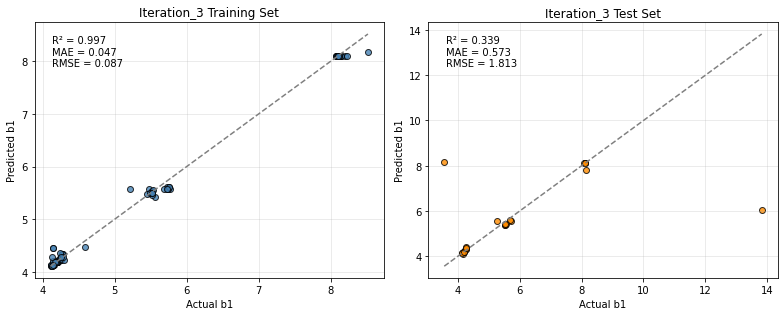


Iteration_4
Model performance:
           R2     MAE    RMSE
Train  0.9953  0.0400  0.1244
Test   0.9479  0.1683  0.3427


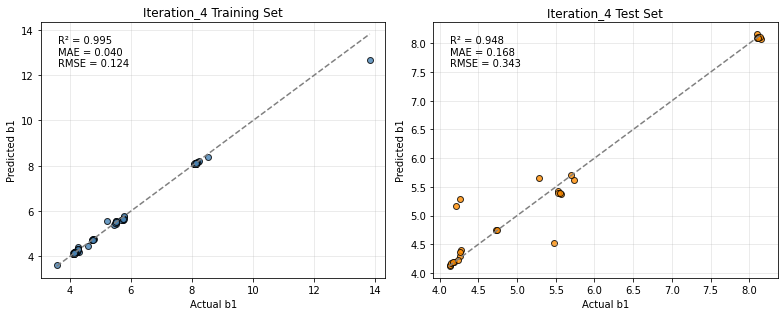


Iteration_5
Model performance:
           R2     MAE    RMSE
Train  0.9938  0.0672  0.1550
Test   0.6851  0.3160  1.0837


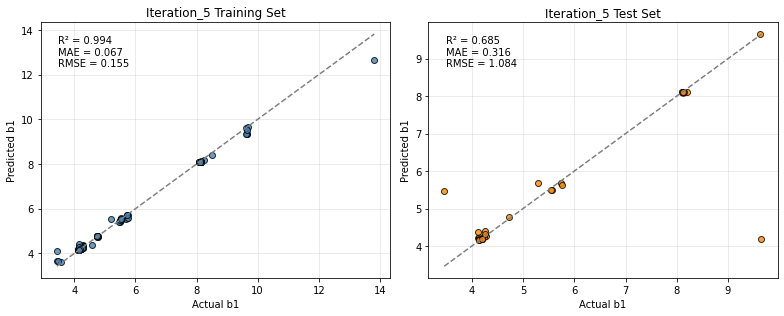


Iteration_6
Model performance:
           R2     MAE    RMSE
Train  0.9911  0.1052  0.1981
Test   0.9933  0.0773  0.1263


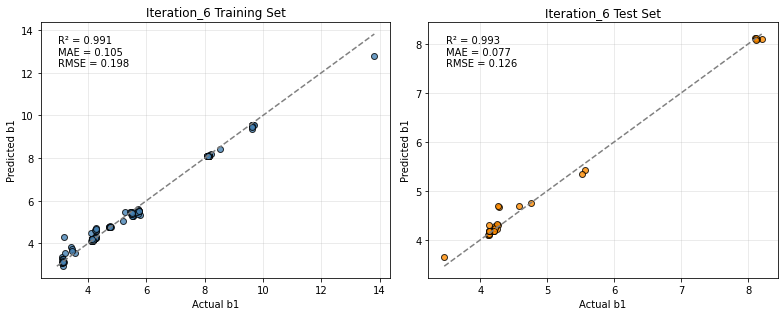

In [5]:
# ============================================================
# 4. Train and evaluate the models
# ============================================================

os.makedirs(
    "figure/b1_iterations",
    exist_ok=True
)


def calculate_metrics(
    y_true,
    y_pred
):

    return {
        "R2": r2_score(
            y_true,
            y_pred
        ),
        "MAE": mean_absolute_error(
            y_true,
            y_pred
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_true,
                y_pred
            )
        )
    }


# Store all iteration metrics
all_metrics = []


for iteration_name, iteration in iteration_data.items():

    X_train_selected = (
        iteration["X_train_selected"]
    )

    X_test_selected = (
        iteration["X_test_selected"]
    )

    y_train = iteration["y_train"]
    y_test = iteration["y_test"]


    # Train the final model
    reg = XGBRegressor(
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        reg_alpha=1,
        reg_lambda=1,
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05
    )

    reg.fit(
        X_train_selected,
        y_train
    )


    # Predictions
    train_pred = reg.predict(
        X_train_selected
    )

    test_pred = reg.predict(
        X_test_selected
    )


    # Calculate metrics using original b1 values
    train_metrics = calculate_metrics(
        y_train,
        train_pred
    )

    test_metrics = calculate_metrics(
        y_test,
        test_pred
    )

    metrics_table = pd.DataFrame(
        [train_metrics, test_metrics],
        index=["Train", "Test"]
    )


    print("\n" + "=" * 70)
    print(iteration_name)
    print("=" * 70)

    print("Model performance:")
    print(
        metrics_table.round(4)
    )


    # Store metrics
    all_metrics.append({
        "Iteration": iteration_name,
        "Dataset": "Train",
        "Sample_Size": len(y_train),
        **train_metrics
    })

    all_metrics.append({
        "Iteration": iteration_name,
        "Dataset": "Test",
        "Sample_Size": len(y_test),
        **test_metrics
    })


    # Store model results
    iteration["reg"] = reg
    iteration["train_pred"] = train_pred
    iteration["test_pred"] = test_pred
    iteration["train_metrics"] = train_metrics
    iteration["test_metrics"] = test_metrics


    # ========================================================
    # Plot model performance
    # ========================================================

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(11, 4.5)
    )


    # Training set
    axes[0].scatter(
        y_train,
        train_pred,
        color="steelblue",
        edgecolor="black",
        alpha=0.8
    )

    train_min = min(
        y_train.min(),
        train_pred.min()
    )

    train_max = max(
        y_train.max(),
        train_pred.max()
    )

    axes[0].plot(
        [train_min, train_max],
        [train_min, train_max],
        color="gray",
        linestyle="--"
    )

    axes[0].set_xlabel("Actual b1")
    axes[0].set_ylabel("Predicted b1")

    axes[0].set_title(
        f"{iteration_name} Training Set"
    )

    axes[0].text(
        0.05,
        0.95,
        (
            f"R² = {train_metrics['R2']:.3f}\n"
            f"MAE = {train_metrics['MAE']:.3f}\n"
            f"RMSE = {train_metrics['RMSE']:.3f}"
        ),
        transform=axes[0].transAxes,
        verticalalignment="top"
    )

    axes[0].grid(alpha=0.3)


    # Test set
    axes[1].scatter(
        y_test,
        test_pred,
        color="darkorange",
        edgecolor="black",
        alpha=0.8
    )

    test_min = min(
        y_test.min(),
        test_pred.min()
    )

    test_max = max(
        y_test.max(),
        test_pred.max()
    )

    axes[1].plot(
        [test_min, test_max],
        [test_min, test_max],
        color="gray",
        linestyle="--"
    )

    axes[1].set_xlabel("Actual b1")
    axes[1].set_ylabel("Predicted b1")

    axes[1].set_title(
        f"{iteration_name} Test Set"
    )

    axes[1].text(
        0.05,
        0.95,
        (
            f"R² = {test_metrics['R2']:.3f}\n"
            f"MAE = {test_metrics['MAE']:.3f}\n"
            f"RMSE = {test_metrics['RMSE']:.3f}"
        ),
        transform=axes[1].transAxes,
        verticalalignment="top"
    )

    axes[1].grid(alpha=0.3)

    plt.tight_layout()

    plt.show()


In [6]:
# ============================================================
# 5. Save models, selected features and results
# ============================================================

os.makedirs(
    "model/b1_iterations",
    exist_ok=True
)

os.makedirs(
    "result/b1_iterations",
    exist_ok=True
)


for iteration_name, iteration in iteration_data.items():

    iteration_number = (
        iteration_name.split("_")[-1]
    )

    reg = iteration["reg"]

    selected_features = (
        iteration["selected_features"]
    )

    y_train = iteration["y_train"]
    y_test = iteration["y_test"]

    train_pred = iteration["train_pred"]
    test_pred = iteration["test_pred"]


    # Save model
    joblib.dump(
        reg,
        (
            "model/b1_iterations/"
            f"xgb_structural_b1_{iteration_number}.pkl"
        )
    )


    # Save selected features
    np.save(
        (
            "model/b1_iterations/"
            f"selected_features_structural_b1_"
            f"{iteration_number}.npy"
        ),
        np.array(selected_features)
    )


    # Save training predictions
    train_predictions = pd.DataFrame({
        "Actual_b1": np.asarray(y_train),
        "Predicted_b1": train_pred
    })

    train_predictions.to_csv(
        (
            "result/b1_iterations/"
            f"Iteration_{iteration_number}_"
            "train_predictions.csv"
        ),
        index=False
    )


    # Save test predictions
    test_predictions = pd.DataFrame({
        "Actual_b1": np.asarray(y_test),
        "Predicted_b1": test_pred
    })

    test_predictions.to_csv(
        (
            "result/b1_iterations/"
            f"Iteration_{iteration_number}_"
            "test_predictions.csv"
        ),
        index=False
    )

    print(
        f"Iteration_{iteration_number} files saved."
    )


# Save all iteration metrics
all_metrics_table = pd.DataFrame(
    all_metrics
)

all_metrics_table.to_csv(
    "result/b1_iterations/"
    "b1_iteration_metrics.csv",
    index=False
)


# Display test-set comparison
test_metrics_table = (
    all_metrics_table[
        all_metrics_table["Dataset"] == "Test"
    ]
    .reset_index(drop=True)
)

print("\n" + "=" * 70)
print("Test performance comparison")
print("=" * 70)

print(
    test_metrics_table.round(4)
)

Iteration_3 files saved.
Iteration_4 files saved.
Iteration_5 files saved.
Iteration_6 files saved.

Test performance comparison
     Iteration Dataset  Sample_Size      R2     MAE    RMSE
0  Iteration_3    Test           25  0.3392  0.5735  1.8129
1  Iteration_4    Test           27  0.9479  0.1683  0.3427
2  Iteration_5    Test           29  0.6851  0.3160  1.0837
3  Iteration_6    Test           32  0.9933  0.0773  0.1263


## c1

In [1]:
# ============================================================
# 1. Import packages
# ============================================================

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

In [2]:
# ============================================================
# 2. Load data and randomly split each dataset
# ============================================================

DATA_FILES = {
    "Iteration_3": "data/compound_3_Structural_c1.csv",
    "Iteration_4": "data/compound_4_Structural_c1.csv",
    "Iteration_5": "data/compound_5_Structural_c1.csv",
    "Iteration_6": "data/compound_6_Structural_c1.csv"
}

TARGET_COL = "c_1"
COMPOUND_COL = "compound"

RANDOM_STATE = 42
TEST_SIZE = 0.20


# Store data from all iterations
iteration_data = {}


for iteration_name, data_file in DATA_FILES.items():

    # Load data
    data = pd.read_csv(data_file)

    # Remove automatically generated index columns
    data = data.loc[
        :,
        ~data.columns.str.startswith("Unnamed")
    ].copy()

    # Features
    X = (
        data
        .drop(
            columns=[
                TARGET_COL,
                COMPOUND_COL
            ],
            errors="ignore"
        )
        .apply(
            pd.to_numeric,
            errors="raise"
        )
    )

    # Target
    y = (
        data[TARGET_COL]
        .astype(float)
    )

    # Randomly split each dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE
    )

    # Store the current iteration data
    iteration_data[iteration_name] = {
        "data_file": data_file,
        "data": data,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test
    }

    print("\n" + "=" * 70)
    print(iteration_name)
    print("=" * 70)

    print("Dataset shape:", data.shape)
    print("Training samples:", len(X_train))
    print("Test samples:", len(X_test))

    print(
        "Training target range:",
        round(y_train.min(), 4),
        "to",
        round(y_train.max(), 4)
    )

    print(
        "Test target range:",
        round(y_test.min(), 4),
        "to",
        round(y_test.max(), 4)
    )




Iteration_3
Dataset shape: (125, 27)
Training samples: 100
Test samples: 25
Training target range: 4.1115 to 8.5201
Test target range: 3.6918 to 8.1464

Iteration_4
Dataset shape: (133, 27)
Training samples: 106
Test samples: 27
Training target range: 3.1742 to 8.5201
Test target range: 3.1798 to 8.1464

Iteration_5
Dataset shape: (145, 27)
Training samples: 116
Test samples: 29
Training target range: 3.1533 to 8.5201
Test target range: 3.1538 to 8.2027

Iteration_6
Dataset shape: (160, 27)
Training samples: 128
Test samples: 32
Training target range: 3.1533 to 13.276
Test target range: 3.1742 to 8.2027


In [3]:
# ============================================================
# 3. Feature selection
# ============================================================

for iteration_name, iteration in iteration_data.items():

    X_train = iteration["X_train"]
    X_test = iteration["X_test"]
    y_train = iteration["y_train"]

    # Initial model for feature selection
    reg_selector = XGBRegressor(
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        reg_alpha=1,
        reg_lambda=1,
        n_estimators=200,
        max_depth=8,
        learning_rate=0.1
    )

    reg_selector.fit(
        X_train,
        y_train
    )

    # Extract feature importance
    feature_importance = (
        reg_selector.feature_importances_
    )

    feature_names = (
        X_train.columns.to_numpy()
    )

    # Keep the top 15 features
    num_features_to_keep = min(
        15,
        X_train.shape[1]
    )

    top_idx = np.argsort(
        feature_importance
    )[::-1][:num_features_to_keep]

    selected_features = (
        feature_names[top_idx]
        .tolist()
    )

    # Select training and test features
    X_train_selected = (
        X_train[selected_features]
        .copy()
    )

    X_test_selected = (
        X_test[selected_features]
        .copy()
    )

    # Store feature-selection results
    iteration["reg_selector"] = reg_selector

    iteration["selected_features"] = (
        selected_features
    )

    iteration["X_train_selected"] = (
        X_train_selected
    )

    iteration["X_test_selected"] = (
        X_test_selected
    )

    print("\n" + "=" * 70)
    print(iteration_name)
    print("=" * 70)

    print("Selected features:")
    print(selected_features)



Iteration_3
Selected features:
['C_AN', 'C_CR', 'AB_AN', 'AB_FIE', 'AB_Nd', 'AB_Nv', 'AB_SIE', 'AB_CR', 'AB_AR', 'AB_EA', 'C_AW', 'AB_AW', 'AB_TC', 'AB_EN', 'AB_EC']

Iteration_4
Selected features:
['C_CR', 'C_AN', 'AB_Nv', 'C_SIE', 'AB_FIE', 'AB_D', 'AB_AN', 'C_VR', 'AB_SIE', 'AB_AR', 'AB_Nd', 'AB_EC', 'AB_CR', 'AB_AW', 'C_AW']

Iteration_5
Selected features:
['C_CR', 'AB_Nv', 'C_AN', 'AB_FIE', 'AB_AR', 'AB_Nd', 'AB_AN', 'AB_D', 'C_VR', 'AB_CR', 'AB_TC', 'AB_SIE', 'AB_EN', 'AB_AW', 'AB_EC']

Iteration_6
Selected features:
['C_AN', 'AB_FIE', 'AB_EC', 'AB_AN', 'AB_AR', 'AB_AW', 'AB_D', 'AB_Nd', 'AB_EN', 'C_VR', 'AB_TC', 'C_D', 'AB_CR', 'AB_SIE', 'C_FIE']



Iteration_3
Model performance:
           R2     MAE    RMSE
Train  0.9980  0.0407  0.0741
Test   0.6476  0.3079  0.8932


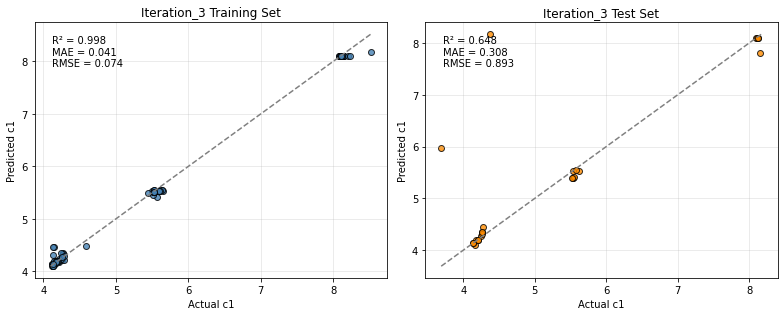


Iteration_4
Model performance:
           R2     MAE    RMSE
Train  0.9963  0.0533  0.1041
Test   0.9798  0.1377  0.2285


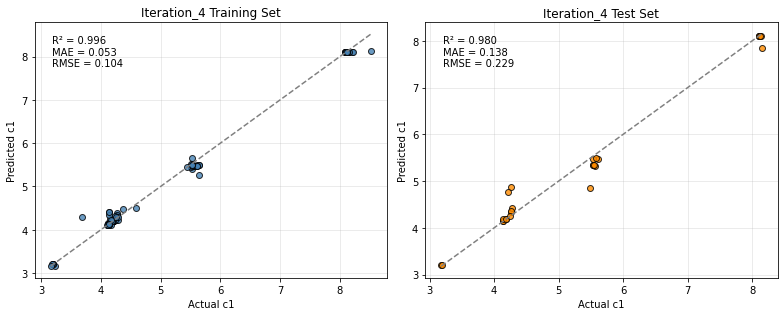


Iteration_5
Model performance:
           R2     MAE    RMSE
Train  0.9941  0.0581  0.1285
Test   0.9949  0.0746  0.1236


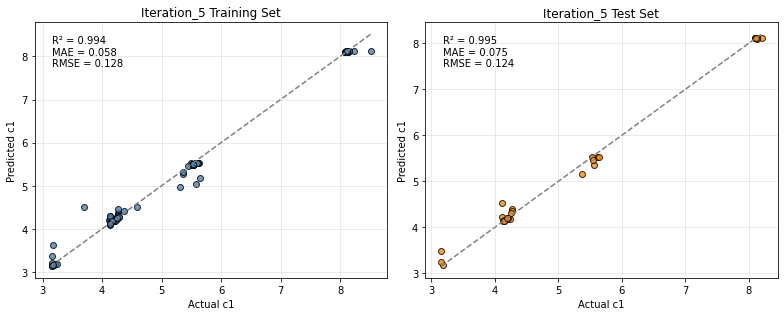


Iteration_6
Model performance:
           R2     MAE    RMSE
Train  0.9983  0.0652  0.1196
Test   0.9927  0.0763  0.1328


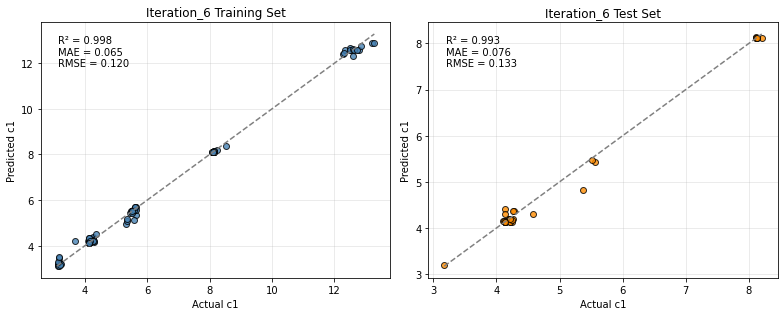

In [4]:
# ============================================================
# 4. Train and evaluate the models
# ============================================================

os.makedirs(
    "figure/c1_iterations",
    exist_ok=True
)


def calculate_metrics(
    y_true,
    y_pred
):

    return {
        "R2": r2_score(
            y_true,
            y_pred
        ),
        "MAE": mean_absolute_error(
            y_true,
            y_pred
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_true,
                y_pred
            )
        )
    }


# Store all iteration metrics
all_metrics = []


for iteration_name, iteration in iteration_data.items():

    X_train_selected = (
        iteration["X_train_selected"]
    )

    X_test_selected = (
        iteration["X_test_selected"]
    )

    y_train = iteration["y_train"]
    y_test = iteration["y_test"]


    # Train the final model
    reg = XGBRegressor(
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        reg_alpha=1,
        reg_lambda=1,
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05
    )

    reg.fit(
        X_train_selected,
        y_train
    )


    # Predictions
    train_pred = reg.predict(
        X_train_selected
    )

    test_pred = reg.predict(
        X_test_selected
    )


    # Calculate metrics using original c1 values
    train_metrics = calculate_metrics(
        y_train,
        train_pred
    )

    test_metrics = calculate_metrics(
        y_test,
        test_pred
    )

    metrics_table = pd.DataFrame(
        [train_metrics, test_metrics],
        index=["Train", "Test"]
    )


    print("\n" + "=" * 70)
    print(iteration_name)
    print("=" * 70)

    print("Model performance:")
    print(
        metrics_table.round(4)
    )


    # Store metrics
    all_metrics.append({
        "Iteration": iteration_name,
        "Dataset": "Train",
        "Sample_Size": len(y_train),
        **train_metrics
    })

    all_metrics.append({
        "Iteration": iteration_name,
        "Dataset": "Test",
        "Sample_Size": len(y_test),
        **test_metrics
    })


    # Store model results
    iteration["reg"] = reg
    iteration["train_pred"] = train_pred
    iteration["test_pred"] = test_pred
    iteration["train_metrics"] = train_metrics
    iteration["test_metrics"] = test_metrics


    # ========================================================
    # Plot model performance
    # ========================================================

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(11, 4.5)
    )


    # Training set
    axes[0].scatter(
        y_train,
        train_pred,
        color="steelblue",
        edgecolor="black",
        alpha=0.8
    )

    train_min = min(
        y_train.min(),
        train_pred.min()
    )

    train_max = max(
        y_train.max(),
        train_pred.max()
    )

    axes[0].plot(
        [train_min, train_max],
        [train_min, train_max],
        color="gray",
        linestyle="--"
    )

    axes[0].set_xlabel("Actual c1")
    axes[0].set_ylabel("Predicted c1")

    axes[0].set_title(
        f"{iteration_name} Training Set"
    )

    axes[0].text(
        0.05,
        0.95,
        (
            f"R² = {train_metrics['R2']:.3f}\n"
            f"MAE = {train_metrics['MAE']:.3f}\n"
            f"RMSE = {train_metrics['RMSE']:.3f}"
        ),
        transform=axes[0].transAxes,
        verticalalignment="top"
    )

    axes[0].grid(alpha=0.3)


    # Test set
    axes[1].scatter(
        y_test,
        test_pred,
        color="darkorange",
        edgecolor="black",
        alpha=0.8
    )

    test_min = min(
        y_test.min(),
        test_pred.min()
    )

    test_max = max(
        y_test.max(),
        test_pred.max()
    )

    axes[1].plot(
        [test_min, test_max],
        [test_min, test_max],
        color="gray",
        linestyle="--"
    )

    axes[1].set_xlabel("Actual c1")
    axes[1].set_ylabel("Predicted c1")

    axes[1].set_title(
        f"{iteration_name} Test Set"
    )

    axes[1].text(
        0.05,
        0.95,
        (
            f"R² = {test_metrics['R2']:.3f}\n"
            f"MAE = {test_metrics['MAE']:.3f}\n"
            f"RMSE = {test_metrics['RMSE']:.3f}"
        ),
        transform=axes[1].transAxes,
        verticalalignment="top"
    )

    axes[1].grid(alpha=0.3)

    plt.tight_layout()

    plt.show()


In [5]:
# ============================================================
# 5. Save models, selected features and results
# ============================================================

os.makedirs(
    "model/c1_iterations",
    exist_ok=True
)

os.makedirs(
    "result/c1_iterations",
    exist_ok=True
)


for iteration_name, iteration in iteration_data.items():

    iteration_number = (
        iteration_name.split("_")[-1]
    )

    reg = iteration["reg"]

    selected_features = (
        iteration["selected_features"]
    )

    y_train = iteration["y_train"]
    y_test = iteration["y_test"]

    train_pred = iteration["train_pred"]
    test_pred = iteration["test_pred"]


    # Save model
    joblib.dump(
        reg,
        (
            "model/c1_iterations/"
            f"xgb_structural_c1_{iteration_number}.pkl"
        )
    )


    # Save selected features
    np.save(
        (
            "model/c1_iterations/"
            f"selected_features_structural_c1_"
            f"{iteration_number}.npy"
        ),
        np.array(selected_features)
    )


    # Save training predictions
    train_predictions = pd.DataFrame({
        "Actual_c1": np.asarray(y_train),
        "Predicted_c1": train_pred
    })

    train_predictions.to_csv(
        (
            "result/c1_iterations/"
            f"Iteration_{iteration_number}_"
            "train_predictions.csv"
        ),
        index=False
    )


    # Save test predictions
    test_predictions = pd.DataFrame({
        "Actual_c1": np.asarray(y_test),
        "Predicted_c1": test_pred
    })

    test_predictions.to_csv(
        (
            "result/c1_iterations/"
            f"Iteration_{iteration_number}_"
            "test_predictions.csv"
        ),
        index=False
    )

    print(
        f"Iteration_{iteration_number} files saved."
    )


# Save all iteration metrics
all_metrics_table = pd.DataFrame(
    all_metrics
)

all_metrics_table.to_csv(
    "result/c1_iterations/"
    "c1_iteration_metrics.csv",
    index=False
)


# Display test-set comparison
test_metrics_table = (
    all_metrics_table[
        all_metrics_table["Dataset"] == "Test"
    ]
    .reset_index(drop=True)
)

print("\n" + "=" * 70)
print("Test performance comparison")
print("=" * 70)

print(
    test_metrics_table.round(4)
)

Iteration_3 files saved.
Iteration_4 files saved.
Iteration_5 files saved.
Iteration_6 files saved.

Test performance comparison
     Iteration Dataset  Sample_Size      R2     MAE    RMSE
0  Iteration_3    Test           25  0.6476  0.3079  0.8932
1  Iteration_4    Test           27  0.9798  0.1377  0.2285
2  Iteration_5    Test           29  0.9949  0.0746  0.1236
3  Iteration_6    Test           32  0.9927  0.0763  0.1328
